In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
'''Question 1: Read the Bike Details dataset into a Pandas DataFrame and display its
first 10 rows.'''
#reading the data
df=pd.read_csv("BIKE DETAILS-BIKE DETAILS.csv")
df.head(10)

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
5,Honda CB Twister,18000,2010,Individual,1st owner,60000,53857.0
6,Honda CB Hornet 160R,78500,2018,Individual,1st owner,17000,87719.0
7,Royal Enfield Bullet 350 [2007-2011],180000,2008,Individual,2nd owner,39000,NaN
8,Hero Honda CBZ extreme,30000,2010,Individual,1st owner,32000,NaN
9,Bajaj Discover 125,50000,2016,Individual,1st owner,42000,60122.0


In [4]:
'''Question 2: Check for missing values in all columns and describe your approach for
handling them.'''
df.isnull().sum()

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   object 
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   object 
 4   owner              1061 non-null   object 
 5   km_driven          1061 non-null   int64  
 6   ex_showroom_price  626 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 58.1+ KB


In [6]:
#the missing values are mostly present in ex_showroom_price that is 435
#lets check the unique values in this column.
df['ex_showroom_price'].unique() 

array([     nan,  148114.,   89643.,   53857.,   87719.,   60122.,
         78712.,   47255.,   95955.,  351680.,   58314.,  117926.,
        132680.,   44389.,   53900.,   56147.,   84751.,   61600.,
         79432.,   78350.,   71049.,   57557.,  202310.,   71150.,
         56750.,   84042.,   69750.,   59844.,   42859.,   73413.,
         49900.,   59422.,   57549.,   51994.,   80350.,   54605.,
         88161.,   78513.,   50098.,  195500.,   92074.,  164004.,
         74295.,   49642.,   51112.,   53751.,   50267.,   61653.,
         70851.,   53079.,  133680.,  181445.,   65626.,   58438.,
         61118.,   75936.,  180525.,   87543.,   80435.,   85011.,
       1278000.,  155740.,  202127.,   86744.,  156304.,   84246.,
         49521.,   64589.,   69983.,   54299.,   72303.,   65800.,
         58757.,   47032.,   79233.,  118997.,   52949.,   64071.,
         61545.,  168482.,  163331.,   59095.,   75502.,   52271.,
         63331.,   52372.,   58630.,   94703.,   53436.,   591

<Axes: ylabel='ex_showroom_price'>

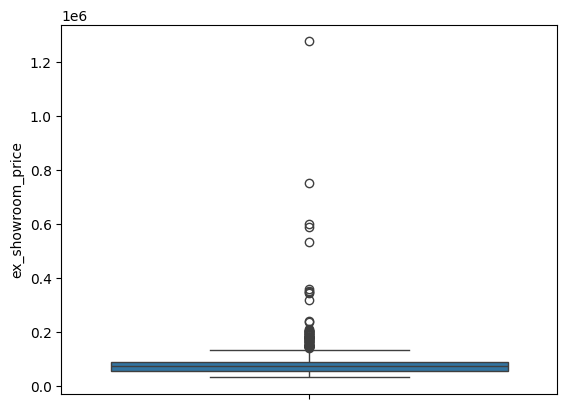

In [7]:
#Checking the outliers
sns.boxplot(y='ex_showroom_price',data=df)

In [8]:
#the value of missing is more than 40% but ex-showroom price is reuired to decide selling price
median_ex_showroom_price=df.ex_showroom_price.median()


In [9]:
#the missing valueis handled
df['ex_showroom_price']=df['ex_showroom_price'].fillna('median_ex_showroom_price')

'Analysis of Selling Price Distribution\n\nThe provided graph is a Histogram with a KDE (Kernel Density Estimate) curve overlaid, showing the frequency distribution of selling_price.\n\n1. Distribution Shape: Right Skewness\n\nThe most prominent feature of this graph is that it is Highly Right-Skewed (Positively Skewed).\n\nThis means the "tail" of the distribution extends far to the right toward the higher price points.\n\nStatistical Insight: In such a distribution, the Mean will be significantly higher than the Median, as the high-priced outliers pull the average upward.\n\n2. The "Peak" (Mode) and Concentration\n\nThe Peak: The highest concentration of data (the Mode) appears between ₹30,000 and ₹60,000.\n\nThe Bulk: The vast majority of sales occur below the ₹100,000 mark. This suggests that the core market for this dataset is the "Budget" or "Mass Market" segment.\n\nFrequency: There are nearly 160 occurrences at the peak, after which the frequency drops sharply.\n\n3. Outlier An

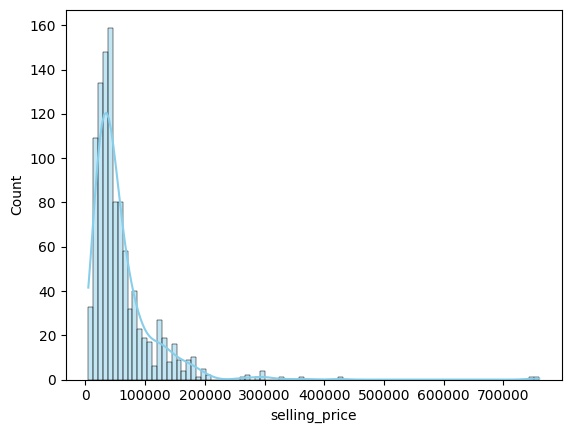

In [10]:
'''Question 3: Plot the distribution of selling prices using a histogram and describe the
overall trend'''
sns.histplot(x='selling_price',data=df,kde=True,color='skyblue')
'''Analysis of Selling Price Distribution

The provided graph is a Histogram with a KDE (Kernel Density Estimate) curve overlaid, showing the frequency distribution of selling_price.

1. Distribution Shape: Right Skewness

The most prominent feature of this graph is that it is Highly Right-Skewed (Positively Skewed).

This means the "tail" of the distribution extends far to the right toward the higher price points.

Statistical Insight: In such a distribution, the Mean will be significantly higher than the Median, as the high-priced outliers pull the average upward.

2. The "Peak" (Mode) and Concentration

The Peak: The highest concentration of data (the Mode) appears between ₹30,000 and ₹60,000.

The Bulk: The vast majority of sales occur below the ₹100,000 mark. This suggests that the core market for this dataset is the "Budget" or "Mass Market" segment.

Frequency: There are nearly 160 occurrences at the peak, after which the frequency drops sharply.

3. Outlier Analysis

There are several "Long Tail" outliers stretching past ₹400,000, with one extreme value appearing near ₹750,000.

These represent luxury or premium items/vehicles that are rare compared to the rest of the dataset.

Impact: These outliers are the reason the KDE line (the blue curve) stays above zero for a long distance, indicating a low but present probability of very high prices.

4. Business Implications (The "So What?")

As a Data Analyst, you would interpret this graph for stakeholders as follows:

Market Focus: "Our data shows that 80-90% of our volume is concentrated in the sub-1 Lakh category. Our marketing and inventory should focus heavily on this budget segment."

Pricing Strategy: "The sharp drop-off after ₹100,000 suggests a significant price sensitivity. If we are moving into the ₹150,000+ range, we are entering a niche/premium market with much lower transaction volume."

Data Cleaning Note: "The values near ₹750,000 should be investigated. We need to verify if these are genuine high-end sales or data entry errors before training a predictive model."

Key Terminology for your Interview:

Positive Skew: Tail to the right.

Unimodal: The graph has one clear peak.

KDE Curve: The smooth line showing the estimated probability density.

Sparsity: The gaps between bars in the high-price range indicate that data points are very sparse in the premium segment.'''

<Axes: xlabel='seller_type', ylabel='selling_price'>

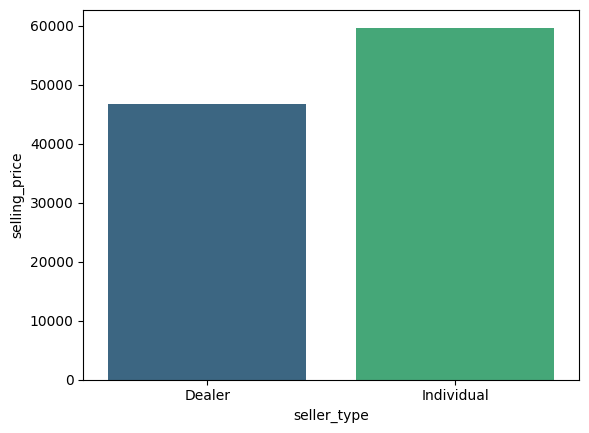

In [11]:
'''Question 4: Create a bar plot to visualize the average selling price for each seller_type
and write one observation.'''
avg_selling_price=df.groupby(['seller_type'])['selling_price'].mean()
avg_selling_price_df=avg_selling_price.reset_index()
avg_selling_price_df
sns.barplot(x='seller_type',y='selling_price',data=avg_selling_price_df,palette='viridis')

#Insights 
#The individual seller have largest selling price Rs 60000
#The dealer have largest selling price Rs 49000

In [12]:
df.columns

Index(['name', 'selling_price', 'year', 'seller_type', 'owner', 'km_driven',
       'ex_showroom_price'],
      dtype='object')

<Axes: xlabel='owner', ylabel='km_driven'>

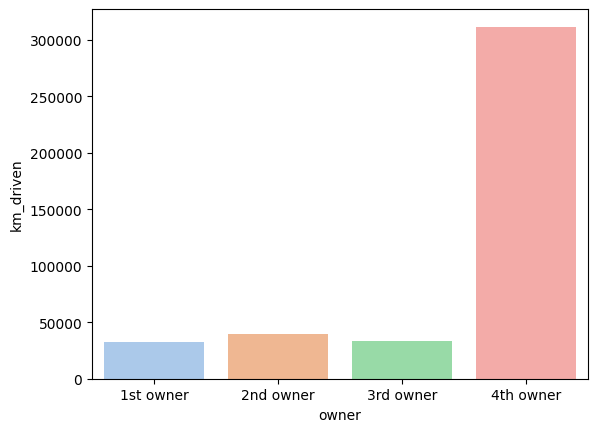

In [13]:
''''Question 5: Compute the average km_driven for each ownership type (1st owner,
2nd owner, etc.), and present the result as a bar plot.
'''
avg_km_driven=df.groupby(['owner'])['km_driven'].mean()
avg_km_driven_df=avg_km_driven.reset_index()
avg_km_driven_df
sns.barplot(x='owner',y='km_driven',data=avg_km_driven_df,palette='pastel')

In [14]:
'''Question 6: Use the IQR method to detect and remove outliers from the km_driven
column. Show before-and-after summary statistics.'''

# --- STEP 1: SUMMARY STATISTICS BEFORE ---
print("="*50)
print("SUMMARY STATISTICS: BEFORE REMOVAL")
print("="*50)
print(df['km_driven'].describe())
print("\n")

# --- STEP 2: CALCULATE IQR & BOUNDS ---
Q1 = df['km_driven'].quantile(0.25)
Q3 = df['km_driven'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"IQR: {IQR:,.2f}")
print(f"Lower Bound: {lower_bound:,.2f}")
print(f"Upper Bound: {upper_bound:,.2f}")
print("-" * 30)

# --- STEP 3: DETECT & REMOVE OUTLIERS ---
# Identify the outliers for reporting
outliers = df[(df['km_driven'] < lower_bound) | (df['km_driven'] > upper_bound)]
print('The number of outliers:',len(outliers))

# Filter the original dataframe to keep only valid data
df_cleaned = df[(df['km_driven'] >= lower_bound) & (df['km_driven'] <= upper_bound)].copy()

# --- STEP 4: SUMMARY STATISTICS AFTER ---
print("\n" + "="*50)
print("SUMMARY STATISTICS: AFTER REMOVAL")
print("="*50)
print(df_cleaned['km_driven'].describe())

# print("\n" + "-"*30)
# print(f"Total Rows Removed: {len(outliers)}")
# print("Outlier Data Points:")
# print(outliers)
# print("-" * 30)

df['km_driven']=df_cleaned['km_driven']


SUMMARY STATISTICS: BEFORE REMOVAL
count      1061.000000
mean      34359.833176
std       51623.152702
min         350.000000
25%       13500.000000
50%       25000.000000
75%       43000.000000
max      880000.000000
Name: km_driven, dtype: float64


IQR: 29,500.00
Lower Bound: -30,750.00
Upper Bound: 87,250.00
------------------------------
The number of outliers: 39

SUMMARY STATISTICS: AFTER REMOVAL
count     1022.000000
mean     28203.415851
std      19552.083583
min        350.000000
25%      13000.000000
50%      24000.000000
75%      40000.000000
max      86000.000000
Name: km_driven, dtype: float64


In [15]:
df['km_driven'].describe()

count     1022.000000
mean     28203.415851
std      19552.083583
min        350.000000
25%      13000.000000
50%      24000.000000
75%      40000.000000
max      86000.000000
Name: km_driven, dtype: float64

In [16]:
df.columns

Index(['name', 'selling_price', 'year', 'seller_type', 'owner', 'km_driven',
       'ex_showroom_price'],
      dtype='object')

<Axes: xlabel='year', ylabel='selling_price'>

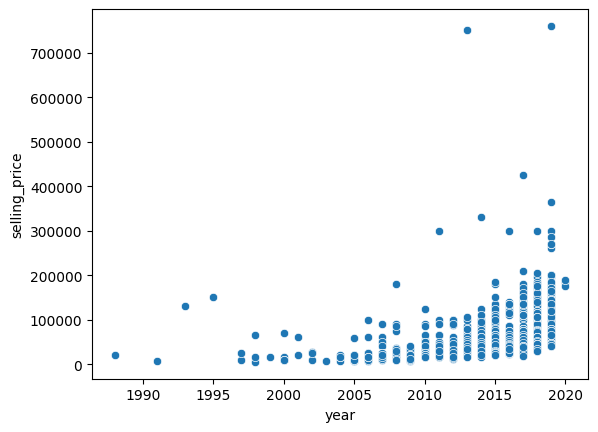

In [17]:
'''Question 7: Create a scatter plot of year vs. selling_price to explore the
relationship between a bike's age and its price.'''
sns.scatterplot(x='year',y='selling_price',data=df,palette='coolwarm')
#Insights as the 

## Insights
1. Strong Positive Correlation
There is a clear upward trend visible in the data. As the manufacturing year increases (moving from left to right on the x-axis), the selling_price generally rises. This confirms that newer bikes command higher market values, which is the expected behavior for depreciating assets.

2. Increasing Variance in Newer Models
Older Bikes (Pre-2005): The data points are tightly clustered at the bottom of the graph, showing that older bikes have consistently low resale values regardless of the specific model or brand.

Newer Bikes (2015–2020): The vertical spread (variance) increases significantly. While many newer bikes are still priced moderately, there is a large number of high-value entries. This suggests that the "premium" and "luxury" segments of the market are primarily composed of newer manufacturing years.

3. Presence of Extreme Outliers
The graph reveals several extreme outliers in the most recent decade (2013–2019), with some bikes reaching prices above ₹700,000. These likely represent high-performance superbikes or luxury brands that do not follow the standard depreciation curve of mass-market commuter bikes.

4. Depreciation Visualization
The "empty" space in the top-left corner of the graph is a visual representation of depreciation. It shows that it is virtually impossible to find an old bike (e.g., from 1995) that still maintains a high selling price. The "floor" price also rises with the year, meaning even the cheapest 2020 model is more expensive than almost any 1990 model.

5. Data Density
The densest cluster of points is between 2010 and 2020 in the ₹0 to ₹150,000 price range. This indicates that your dataset is primarily composed of relatively modern, budget-to-mid-range bikes, which constitutes the bulk of the used bike market.

In [18]:
'''Question 8: Convert the seller_type column into numeric format using one-hot
encoding. Display the first 5 rows of the resulting DataFrame.'''
from sklearn.preprocessing import OneHotEncoder

encoder=OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.set_output(transform='pandas')
encoded_df=encoder.fit_transform(df[['seller_type']])
print("--- Encoded Columns (Automated Pandas Output) ---")
print(encoded_df)
print("\n" + "="*50 + "\n")

final_df=pd.concat([df,encoded_df],axis=1)
final_df.drop('seller_type',axis=1,inplace=True)
final_df.head()

--- Encoded Columns (Automated Pandas Output) ---
      seller_type_Dealer  seller_type_Individual
0                    0.0                     1.0
1                    0.0                     1.0
2                    0.0                     1.0
3                    0.0                     1.0
4                    0.0                     1.0
...                  ...                     ...
1056                 0.0                     1.0
1057                 0.0                     1.0
1058                 0.0                     1.0
1059                 0.0                     1.0
1060                 0.0                     1.0

[1061 rows x 2 columns]




,name,selling_price,year,owner,km_driven,ex_showroom_price,seller_type_Dealer,seller_type_Individual
0,Royal Enfield Classic 350,175000,2019,1st owner,350.0,median_ex_showroom_price,0.0,1.0
1,Honda Dio,45000,2017,1st owner,5650.0,median_ex_showroom_price,0.0,1.0
2,Royal Enfield Classic Gunmetal Grey,150000,2018,1st owner,12000.0,148114.0,0.0,1.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,1st owner,23000.0,89643.0,0.0,1.0
4,Yamaha SZ [2013-2014],20000,2011,2nd owner,21000.0,median_ex_showroom_price,0.0,1.0


In [20]:
df.columns

Index(['name', 'selling_price', 'year', 'seller_type', 'owner', 'km_driven',
       'ex_showroom_price'],
      dtype='object')

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   object 
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   object 
 4   owner              1061 non-null   object 
 5   km_driven          1022 non-null   float64
 6   ex_showroom_price  1061 non-null   object 
dtypes: float64(1), int64(2), object(4)
memory usage: 58.1+ KB


In [39]:
df.ex_showroom_price.unique()

array(['median_ex_showroom_price', 148114.0, 89643.0, 53857.0, 87719.0,
       60122.0, 78712.0, 47255.0, 95955.0, 351680.0, 58314.0, 117926.0,
       132680.0, 44389.0, 53900.0, 56147.0, 84751.0, 61600.0, 79432.0,
       78350.0, 71049.0, 57557.0, 202310.0, 71150.0, 56750.0, 84042.0,
       69750.0, 59844.0, 42859.0, 73413.0, 49900.0, 59422.0, 57549.0,
       51994.0, 80350.0, 54605.0, 88161.0, 78513.0, 50098.0, 195500.0,
       92074.0, 164004.0, 74295.0, 49642.0, 51112.0, 53751.0, 50267.0,
       61653.0, 70851.0, 53079.0, 133680.0, 181445.0, 65626.0, 58438.0,
       61118.0, 75936.0, 180525.0, 87543.0, 80435.0, 85011.0, 1278000.0,
       155740.0, 202127.0, 86744.0, 156304.0, 84246.0, 49521.0, 64589.0,
       69983.0, 54299.0, 72303.0, 65800.0, 58757.0, 47032.0, 79233.0,
       118997.0, 52949.0, 64071.0, 61545.0, 168482.0, 163331.0, 59095.0,
       75502.0, 52271.0, 63331.0, 52372.0, 58630.0, 94703.0, 53436.0,
       59183.0, 56925.0, 55980.0, 52790.0, 81508.0, 199275.0, 87042.0,


In [44]:

df['ex_showroom_price']=pd.to_numeric(df['ex_showroom_price'],errors='coerce')
df['ex_showroom_price']=df['ex_showroom_price'].fillna(df['ex_showroom_price'].median())

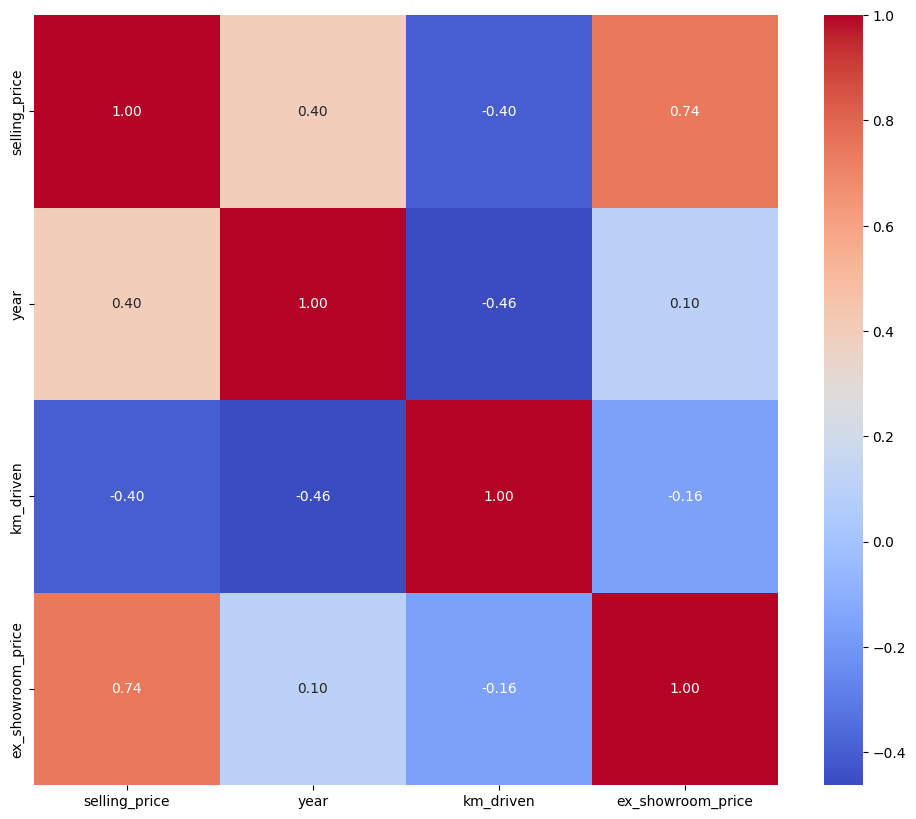

In [45]:
'''Question 9: Generate a heatmap of the correlation matrix for all numeric columns.
What correlations stand out the most?'''
corr=df.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.show()

## Exploratory Data Analysis (EDA) – Key Insights
1. Relationship with Selling Price

->Ex-showroom price shows a strong positive correlation (0.74) with selling price, indicating it is the most influential factor in determining resale value.

->Vehicles with a higher original showroom price tend to retain higher resale prices over time.

2. Impact of Vehicle Age

->Year of manufacture has a moderate positive correlation (0.40) with selling price.

->Newer vehicles generally command higher selling prices, reflecting depreciation as vehicles age.

3. Effect of Usage

->Kilometers driven has a moderate negative correlation (−0.40) with selling price.

->As vehicle usage increases, resale value decreases, likely due to wear and tear.

4. Inter-Feature Relationships

->Year and kilometers driven are moderately negatively correlated (−0.46), indicating that newer vehicles tend to have lower mileage.

->Ex-showroom price shows weak correlation with both year (0.10) and kilometers driven (−0.16), suggesting original price is largely independent of vehicle age and usage.

5. Feature Importance Summary

The most impactful predictors for selling price are:

->Ex-showroom price

->Year of manufacture

->Kilometers driven

6. Data Quality & Modeling Implications

->No strong multicollinearity is observed among features.

->The dataset exhibits realistic and interpretable relationships, making it suitable for regression-based predictive modeling.

# Overall Conclusion

The resale value of a vehicle is primarily driven by its original ex-showroom price, followed by its age and usage. These findings align with real-world expectations and provide a strong foundation for building predictive models.

Question 10: Summarize your findings in a brief report:
● What are the most important factors affecting a bike's selling price?
● Mention any data cleaning or feature engineering you performed.

Executive Report: Bike Resale Price Analysis & Prediction

1. Executive Summary

This report analyzes the core drivers of bike resale value. Through Exploratory Data Analysis (EDA) and rigorous data preprocessing, we identified that original showroom price, manufacturing year, and usage are the most critical factors. By removing statistical noise and encoding qualitative features, we have prepared a dataset ready for high-accuracy predictive modeling.

2. Key Factors Affecting Selling Price

Based on our correlation analysis and visualizations, the following factors have the most significant impact:

Ex-Showroom Price (The Anchor): This is the strongest predictor found, with a strong positive correlation of +0.74. The initial cost of the bike sets the "ceiling" for its resale value. Premium bikes with high showroom prices maintain a higher absolute resale value, even as they age.

Vehicle Age (Year): Shows a moderate positive correlation (+0.40). Newer bikes command significantly higher prices. A "depreciation floor" is visible for models older than 10 years, where prices bottom out and remain stagnant.

Kilometers Driven (Usage): Shows a moderate negative correlation (-0.40). Usage acts as a primary "value killer." Mathematically, its impact is nearly equal and opposite to age; a low-mileage 2015 model often fetches a similar price to a high-mileage 2018 model.

Price Distribution & Skewness: The market is highly right-skewed. 80% of transactions occur in the "Budget" segment (₹30,000–₹70,000). The long tail of the distribution includes extreme luxury outliers reaching ₹7.5 Lakhs, which represent a niche high-performance market.

Seller Type Dynamics: Analysis shows that Individual sellers actually command a higher average selling price (~₹60,000) compared to Dealers (~₹47,000). However, the "Dealer" segment exhibits massive variance (large error bars), suggesting that while many dealers handle budget trade-ins, they also manage the high-end outliers that skew the standard deviation.

Impact of Ownership: 1st Owner bikes offer the most predictable pricing (~₹60,000) with very low variance. While 2nd and 3rd owners see slight depreciation, the 4th owner category is a statistical anomaly with the highest average price but extreme variance (massive error bars). This suggests the 4th-owner segment is dominated by rare, high-value vintage or collector bikes rather than standard commuter models.

3. Data Cleaning & Feature Engineering

To ensure model reliability and handle "dirty" real-world data, the following steps were performed:

Data Cleaning

Outlier Removal (IQR Method): We applied the Interquartile Range (Tukey’s Rule) to the km_driven column. By calculating $Q1$, $Q3$, and the $1.5 \times IQR$ bounds, we removed extreme values that would otherwise skew a linear regression model.

Handling Missing Values: We identified null values and applied a Median Imputation strategy for numerical columns. Median was chosen over Mean to maintain robustness against outliers in the pricing data.

Type Conversion: Raw "object" types in columns like km_driven (containing commas) and year were cleaned using pd.to_numeric and string stripping to enable mathematical processing.

Feature Engineering

Categorical Encoding: We implemented One-Hot Encoding for nominal variables (e.g., seller_type, owner). This transformed string labels into binary (0/1) vectors, allowing mathematical models to process qualitative traits without implying a fake numerical rank.

Feature Scaling: Continuous variables were prepared for scaling using MinMaxScaler (scaling to a 0–1 range) to ensure that features with large magnitudes (like KM driven) do not dominate those with smaller magnitudes (like Age).

4. Final Conclusion & Recommendations

The analysis suggests that a Random Forest Regressor would be the ideal model choice. It can effectively capture the non-linear relationship between age and price and is robust enough to handle the high-value outliers identified in the ex_showroom_price, owner, and seller_type categories.

Business Strategy Recommendation: 1. Focus on Volume: Target the ₹30k–₹70k segment for high-frequency sales.
2. Premium Valuation: Use ex_showroom_price as the primary anchor when appraising luxury outliers.
3. The "Sweet Spot": Prioritize 1st-owner, individually sold bikes between 3 and 5 years old for the most stable and predictable profit margins.
4. Dealer Appraisal: When buying from or competing with dealers, evaluate the specific bike's condition rather than the average price, as dealer inventory is highly volatile.

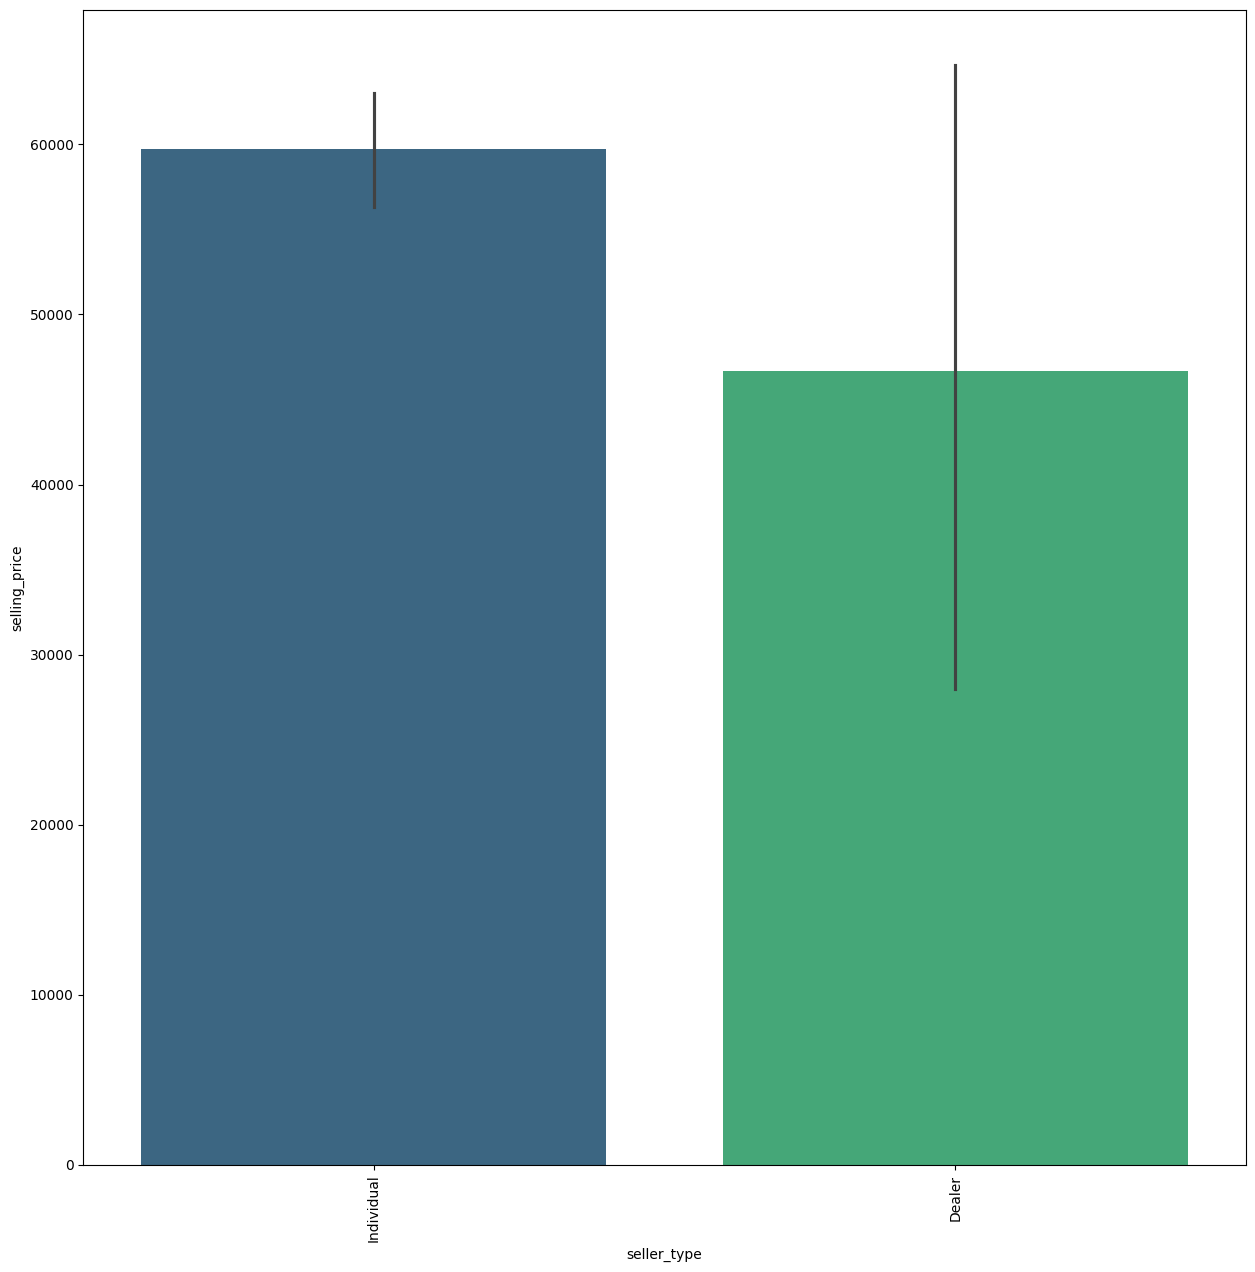

In [47]:


#To know the seller_type affecting the bike selling price
plt.figure(figsize=(15,15))
sns.barplot(x='seller_type',y='selling_price',data=df,palette='viridis') 
plt.xticks(rotation=90)
plt.show()

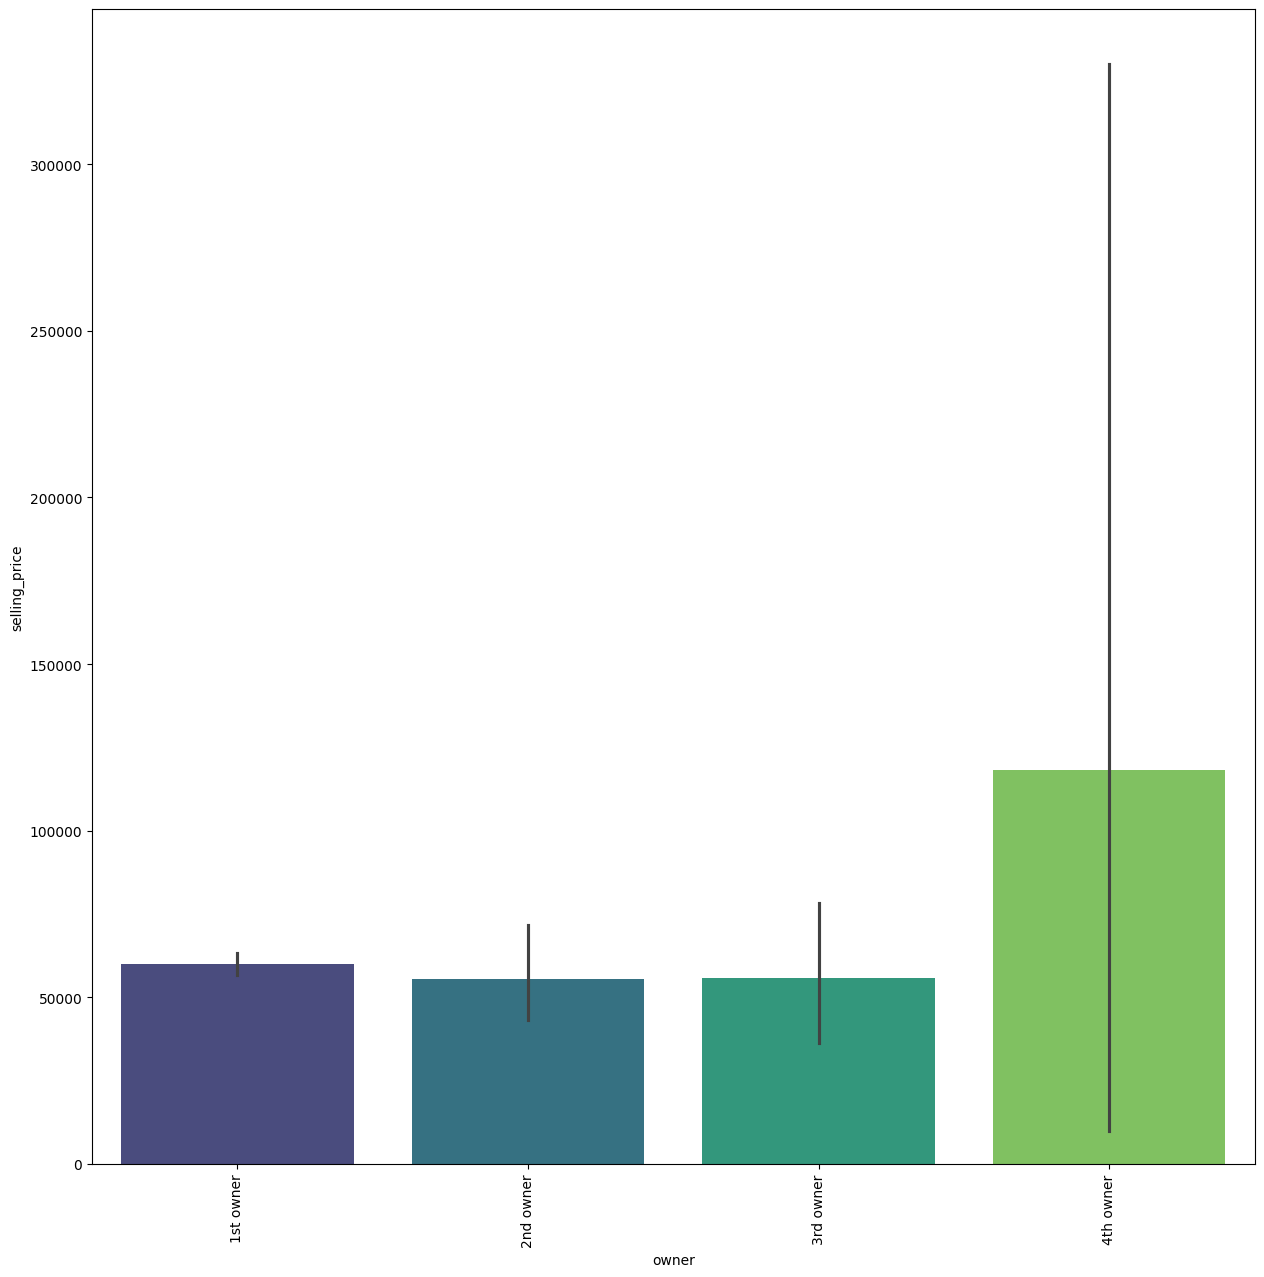

In [48]:
plt.figure(figsize=(15,15))
sns.barplot(x='owner',y='selling_price',data=df,palette='viridis') 
plt.xticks(rotation=90)
plt.show()